# עבודה בלמידת מכונה — סיווג סנטימנט של ציוצים בטוויטר

**סוג הבעיה:** סיווג רב-מחלקתי (Multi-class Classification) לארבע מחלקות — `Positive` / `Negative` / `Neutral` / `Irrelevant`

**אלגוריתם הלמידה:** Multinomial Naive Bayes במימוש עצמאי (חלק 3), מאומת מול המימוש של `scikit-learn`

**מדד האיכות:** Macro-Average F1 — המדד שההנחיות מחייבות בבעיית סיווג רב-מחלקתית שאין בה מחלקה מרכזית אחת

**הנתונים:** `twitter_training.csv` כ-Train ו-`twitter_validation.csv` כ-Test, בדיוק כפי שסופקו — **ללא חלוקה מחדש**

---

### מפת המחברת

| חלק | נושא | ניקוד |
|---|---|---|
| 1 | הקדמה, הצגת הנתונים וטעינה | 5 |
| 2 | ניקוי טקסט והנדסת מאפיינים (Feature Engineering) | 35 |
| 3 | מימוש עצמאי של Naive Bayes | 35 (+5 בונוס) |
| 6א | Grid Search עם 5-Fold Cross Validation | 25 |
| 6ב | התאמת ה-Data: טיפול בחוסר איזון בין המחלקות | 10 |
| 4 | אימון המודל הסופי על כל ה-Train | 5 |
| 5 | חיזוי והערכת איכות על ה-Test | 10 |
| 6ג | הסבירות המודל (Explainability) | 10 |

> **הערה על סדר החלקים:** חלק 6א מופיע במחברת *לפני* חלקים 4 ו-5, מפני שחלק 4 מחייב לאמן את המודל הסופי עם הקומבינציה **המנצחת** — ולכן צריך קודם למצוא אותה.

## חלק 1 — הקדמה, הצגת הנתונים וטעינה

**מה הבעיה?** נתון טקסט של ציוץ מטוויטר שנאסף עבור ישות מסוימת (מותג או משחק — למשל `Borderlands`, `Amazon`, `Microsoft`), ואנחנו צריכים לסווג אותו לאחת מארבע מחלקות סנטימנט:

* **Positive** — הציוץ מביע יחס חיובי כלפי הישות
* **Negative** — הציוץ מביע יחס שלילי
* **Neutral** — הציוץ מדבר על הישות בלי מטען רגשי
* **Irrelevant** — הציוץ פשוט **לא באמת מדבר** על הישות שתחתיה הוא נאסף

**למה Macro-Average F1?** בבעיה רב-מחלקתית שאין בה "מחלקה מרכזית" אחת, ההנחיות מחייבות את המדד הזה. הוא מחשב F1 בנפרד לכל אחת מארבע המחלקות ואז לוקח ממוצע חשבוני פשוט — כלומר כל מחלקה מקבלת משקל זהה, גם המחלקה הקטנה ביותר. זה בדיוק ההבדל בינו לבין Accuracy: מודל שמתעלם לגמרי מהמחלקה הקטנה יכול לקבל Accuracy סביר, אבל ה-Macro-F1 שלו ייענש בחומרה.

**מה עושים בשלב הזה?** המחשב לא יודע לקרוא קובץ בעצמו. אנחנו טוענים את שני קובצי ה-CSV למבנה נתונים שנקרא DataFrame — טבלה עם שורות ועמודות, בדיוק כמו גיליון אקסל. לקבצים אין שורת כותרות (Header), ולכן אנחנו מעבירים `header=None` ונותנים לעמודות שמות בעצמנו.

**חשוב:** ההנחיות אוסרות במפורש לחלק מחדש את הנתונים. קובץ ה-Training הוא ה-Train Set שלנו, וקובץ ה-Validation הוא ה-Test Set שלנו — המבחן הסופי והעיוור שלא נוגעים בו עד חלק 5.

In [1]:
# ============================================================================ #
#  ייבוא ספריות והגדרות גלובליות                                              #
# ============================================================================ #
import ast
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.naive_bayes import MultinomialNB   # ONLY to verify our own implementation

RANDOM_STATE = 42
CLASS_ORDER = ["Negative", "Neutral", "Positive", "Irrelevant"]

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

print(f"numpy {np.__version__} | pandas {pd.__version__}")

numpy 2.4.4 | pandas 3.0.2


In [2]:
# ============================================================================ #
#  טעינת הנתונים                                                              #
# ============================================================================ #
COLUMNS = ["Tweet_ID", "Entity", "Sentiment", "Tweet_Text"]

train_df = pd.read_csv("twitter_training.csv",   names=COLUMNS, header=None)
test_df  = pd.read_csv("twitter_validation.csv", names=COLUMNS, header=None)

print(f"Train set : {train_df.shape[0]:,} rows x {train_df.shape[1]} columns")
print(f"Test  set : {test_df.shape[0]:,} rows x {test_df.shape[1]} columns")

Train set : 74,682 rows x 4 columns
Test  set : 1,000 rows x 4 columns


In [3]:
# Required by the assignment: the first 5 rows of the TRAIN set
train_df.head()

,Tweet_ID,Entity,Sentiment,Tweet_Text
0,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
1,2401,Borderlands,Positive,"I am coming to the borders and I will kill you all,"
2,2401,Borderlands,Positive,"im getting on borderlands and i will kill you all,"
3,2401,Borderlands,Positive,"im coming on borderlands and i will murder you all,"
4,2401,Borderlands,Positive,"im getting on borderlands 2 and i will murder you me all,"


In [4]:
# Required by the assignment: the first 5 rows of the TEST set
test_df.head()

,Tweet_ID,Entity,Sentiment,Tweet_Text
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling for motivation to go for a run the other...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects claims company acted like a 'drug dealer' bb...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it functions so poorly on my @SamsungUS Chromebo...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking, it's a truly awful game."
4,4433,Google,Neutral,Now the President is slapping Americans in the face that he really did commit an unlaw...


## חלק 2 — ניקוי הנתונים והנדסת מאפיינים (Feature Engineering)

השלב הזה מתחלק לשני חצאים, וההבחנה ביניהם היא הדבר החשוב ביותר בחלק הזה:

**1. ניקוי טקסט — פעולה שמתבצעת על כל שורה בנפרד.** הפונקציה מקבלת ציוץ אחד ומחזירה ציוץ מנוקה, בלי לדעת שום דבר על שאר הציוצים בקורפוס. לכן מותר להפעיל אותה על ה-Train ועל ה-Test באותה מידה, ואין בכך שום דליפת מידע.

**2. ייצוג מספרי (Vectorization) — פעולה שלומדת פרמטרים מהנתונים.** בניית אוצר המילים (Vocabulary) ומשקלי ה-IDF הן פעולות שרואות את *כל* הקורפוס. לכן חייבים לבצע `fit` על ה-Train **בלבד**, ועל ה-Test לבצע רק `transform`. אם נלמד את אוצר המילים גם מה-Test, המודל "יציץ" בנתוני המבחן — וזה בדיוק מה שנקרא Data Leakage.

### מה בדיוק מנקים ולמה?

| הפעולה | הסיבה |
|---|---|
| הסרת שורות ללא טקסט | אי אפשר להסיק סנטימנט מטקסט שלא קיים |
| המרה לאותיות קטנות (Lowercasing) | `Good` ו-`good` הן אותה מילה; בלי זה הן שני מאפיינים נפרדים והמודל לומד כל אחד מהם מחצי מהדוגמאות |
| הסרת קישורים (URLs) | קישור הוא מזהה ייחודי כמעט לכל ציוץ — הוא לעולם לא יחזור על עצמו ולכן לא יכול ללמד את המודל כלום |
| הסרת תיוגים (`@user`) | שם המשתמש המתויג הוא רעש, לא רגש |
| הסרת מספרים, סימני פיסוק ותווים מיוחדים | משאירים אותיות בלבד, כדי שאוצר המילים יכיל מילים ולא זבל |
| כיווץ רווחים כפולים | ניקיון טכני לפני הפירוק למילים (Tokenization) |

**הערה קטנה אך חשובה על המימוש:** אנחנו מחליפים כל דבר שמסירים ב**רווח** ולא במחרוזת ריקה. אחרת `"great!Awful"` היה הופך למילה אחת ולא קיימת `greatawful`.

In [5]:
# ============================================================================ #
#  חלק 2א: ניקוי הטקסט                                                        #
# ============================================================================ #
URL_RE     = re.compile(r"http\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")
NONALPHA_RE = re.compile(r"[^a-z\s]")
SPACES_RE  = re.compile(r"\s+")


def clean_tweet(text: str) -> str:
    """Stateless normalisation applied identically to every row of both sets."""
    if not isinstance(text, str):
        return ""
    text = text.lower()                     # 1. lower-case
    text = URL_RE.sub(" ", text)            # 2. drop URLs
    text = MENTION_RE.sub(" ", text)        # 3. drop @mentions
    text = NONALPHA_RE.sub(" ", text)       # 4. keep letters only
    text = SPACES_RE.sub(" ", text).strip() # 5. squeeze whitespace
    return text


# --- drop rows with no tweet body -------------------------------------------- #
# NOTE: we drop them from the TRAIN set only. The test set must stay complete,
# because the assignment's final metric is computed over all 1,000 test rows.
n_before = len(train_df)
train_df = train_df.dropna(subset=["Tweet_Text"]).reset_index(drop=True)

train_df["Clean_Text"] = train_df["Tweet_Text"].apply(clean_tweet)
test_df["Clean_Text"]  = test_df["Tweet_Text"].apply(clean_tweet)

# a tweet that became empty after cleaning carries no signal - drop from TRAIN only
train_df = train_df[train_df["Clean_Text"].str.len() > 0].reset_index(drop=True)

print(f"Train : {n_before:,} -> {len(train_df):,} rows "
      f"({n_before - len(train_df):,} rows removed: empty or unusable text)")
print(f"Test  : {len(test_df):,} rows (untouched, as required for the final metric)")

Train : 74,682 -> 73,624 rows (1,058 rows removed: empty or unusable text)
Test  : 1,000 rows (untouched, as required for the final metric)


In [6]:
# ============================================================================ #
#  הדגמת ה-Feature Engineering על 3 דוגמאות מה-TRAIN (דרישת סעיף 2)           #
# ============================================================================ #
def show_cleaning(df, name, patterns):
    """Show real rows that actually exercise the cleaning rules - not cherry-picked."""
    print("=" * 100)
    print(f"BEFORE / AFTER CLEANING  —  3 examples from the {name} set")
    print("=" * 100)
    for pat in patterns:
        hit = df[df["Tweet_Text"].str.contains(pat, case=False, na=False, regex=True)]
        if len(hit) == 0:
            continue
        row = hit.iloc[0]
        print(f"\n[matched rule: {pat}]  gold label = {row['Sentiment']}")
        print(f"  BEFORE : {row['Tweet_Text'][:160]}")
        print(f"  AFTER  : {row['Clean_Text'][:160]}")


PATTERNS = [r"http|www\.", r"@\w+", r"[0-9]{2,}|!{2,}"]
show_cleaning(train_df, "TRAIN", PATTERNS)

BEFORE / AFTER CLEANING  —  3 examples from the TRAIN set

[matched rule: http|www\.]  gold label = Neutral
  BEFORE : Modern Warfare For $38, Borderlands 3 For $20, And More Great Game Deals (PS4, Xbox One, Switch) unsorted.co/modern-warfare… https://t.co/2n68qoJKhU
  AFTER  : modern warfare for borderlands for and more great game deals ps xbox one switch unsorted co modern warfare

[matched rule: @\w+]  gold label = Positive
  BEFORE : So I spent a few hours making something for fun. . . If you don't know I am a HUGE @Borderlands fan and Maya is one of my favorite characters. So I decided to m
  AFTER  : so i spent a few hours making something for fun if you don t know i am a huge fan and maya is one of my favorite characters so i decided to make myself a wallpa



[matched rule: [0-9]{2,}|!{2,}]  gold label = Positive
  BEFORE : 2010 So I spent a few hours making something for fun. . . If you don't know I am a HUGE RhandlerR fan and Maya is one of my favorite characters. So I decided to
  AFTER  : so i spent a few hours making something for fun if you don t know i am a huge rhandlerr fan and maya is one of my favorite characters so i decided to make mysel


In [7]:
# ============================================================================ #
#  אותה הדגמה על 3 דוגמאות מה-TEST (דרישת סעיף 2)                             #
# ============================================================================ #
show_cleaning(test_df, "TEST", PATTERNS)

BEFORE / AFTER CLEANING  —  3 examples from the TEST set

[matched rule: http|www\.]  gold label = Neutral
  BEFORE : Solo Q and this freak is spinning as fast as he can to lower the FPS. 
I thought they took this bs out

@Rainbow6Game https://t.co/mlvHMu4qeZ
  AFTER  : solo q and this freak is spinning as fast as he can to lower the fps i thought they took this bs out

[matched rule: @\w+]  gold label = Negative
  BEFORE : @Microsoft Why do I pay for WORD when it functions so poorly on my @SamsungUS Chromebook? 🙄
  AFTER  : why do i pay for word when it functions so poorly on my chromebook

[matched rule: [0-9]{2,}|!{2,}]  gold label = Neutral
  BEFORE : Now the President is slapping Americans in the face that he really did commit an unlawful act after his  acquittal! From Discover on Google vanityfair.com/news/
  AFTER  : now the president is slapping americans in the face that he really did commit an unlawful act after his acquittal from discover on google vanityfair com news t


### החצי השני: הפיכת מילים למספרים

מודלים מתמטיים לא מבינים מילים — הם מבינים וקטורים של מספרים. שיטת הייצוג שנלמדה בקורס נקראת **Bag of Words**: בונים אוצר מילים מכל המילים שהופיעו ב-Train, וכל ציוץ הופך לווקטור שאורכו כגודל אוצר המילים, שבו כל תא סופר כמה פעמים המילה הזו הופיעה בציוץ.

שני משתנים שנבדוק אמפירית בחלק 6א, במקום להחליט עליהם מראש:

**א. ספירה (Count) מול שקלול (TF-IDF).** ב-TF-IDF כל ספירה מוכפלת בפקטור שמעניש מילים שמופיעות כמעט בכל הציוצים ומתגמל מילים נדירות וממוקדות. חשוב לדעת: הנוסחה של Multinomial Naive Bayes נגזרת מהנחה של **ספירות שלמות**, ולכן `CountVectorizer` הוא הייצוג ה"נכון" תיאורטית עבור המודל שלנו. בפועל TF-IDF לפעמים עובד טוב יותר, אז נבדוק את שניהם וניתן ל-Cross-Validation להכריע.

**ב. Unigrams מול Bigrams.** `ngram_range=(1,1)` מסתכל על מילים בודדות; `(1,2)` מוסיף גם צמדי מילים עוקבים. הצמדים הם הדרך הזולה שבה מודל "טיפש" יכול לתפוס שלילה: `not good` הוא מאפיין אחד, בעוד שבמודל של מילים בודדות המילה `good` תישאר חיובית.

**ג. גודל אוצר המילים.** הפרמטר `max_features` שומר רק את N המילים השכיחות ביותר. הגבלה ל-5,000 מילים נשמעת סבירה — היא מקטינה את המודל ומסננת מילים נדירות — אבל היא גם זורקת לפח בדיוק את המילים הנדירות והממוקדות שהן הסימן החזק ביותר לסנטימנט. גם זה ייבדק אמפירית ולא יוחלט מראש.

בנוסף אנחנו מסירים מילות עצירה אנגליות (`stop_words="english"`) — מילים כמו `the`, `is`, `at` שמופיעות כמעט בכל ציוץ ואינן נושאות מטען רגשי.

התוצאה היא **מטריצה דלילה (Sparse Matrix)**: בציוץ ממוצע יש כ-15 מילים מתוך אוצר של 5,000, כלומר יותר מ-99% מהתאים הם אפס. שמירה של מטריצה כזו בצורה רגילה הייתה תופסת גיגה-בייטים; פורמט CSR שומר רק את התאים שאינם אפס.

In [8]:
# ============================================================================ #
#  חלק 2ב: ייצוג מספרי - הדגמה עם התצורה הבסיסית (unigrams, counts)           #
#  זו הדגמה בלבד; התצורה הסופית נבחרת ב-Grid Search בחלק 6א                    #
# ============================================================================ #
demo_vec = CountVectorizer(max_features=5000, stop_words="english", ngram_range=(1, 1))

X_demo_train = demo_vec.fit_transform(train_df["Clean_Text"])   # fit + transform on TRAIN
X_demo_test  = demo_vec.transform(test_df["Clean_Text"])        # transform ONLY on TEST

print(f"Train feature matrix : {X_demo_train.shape}  "
      f"({X_demo_train.nnz / np.prod(X_demo_train.shape) * 100:.2f}% non-zero)")
print(f"Test  feature matrix : {X_demo_test.shape}")
print(f"Vocabulary size      : {len(demo_vec.get_feature_names_out()):,}")

# what ONE tweet actually looks like as a vector
vocab = np.array(demo_vec.get_feature_names_out())
row = X_demo_train[0]
active = [(vocab[j], int(row[0, j])) for j in row.indices]
print(f"\nExample - train row 0 (gold = {train_df.iloc[0]['Sentiment']}):")
print(f"  cleaned text    : {train_df.iloc[0]['Clean_Text'][:120]}")
print(f"  active features : {row.nnz} out of {X_demo_train.shape[1]} -> {active[:10]}")

Train feature matrix : (73624, 5000)  (0.16% non-zero)
Test  feature matrix : (1000, 5000)
Vocabulary size      : 5,000

Example - train row 0 (gold = Positive):
  cleaned text    : im getting on borderlands and i will murder you all
  active features : 4 out of 5000 -> [('im', 1), ('getting', 1), ('borderlands', 1), ('murder', 1)]


## חלק 3 — מימוש עצמאי של אלגוריתם הלמידה: Multinomial Naive Bayes

### התיאוריה בקצרה

Naive Bayes הוא מסווג **גנרטיבי**: במקום למתוח גבול בין המחלקות, הוא מדגמן איך כל מחלקה "מייצרת" מסמכים, ואז שואל איזו מחלקה הכי סביר שייצרה את המסמך שלפנינו. לפי חוק בייס:

$$P(c \mid d) = \frac{P(c) \cdot P(d \mid c)}{P(d)} \propto P(c) \cdot P(d \mid c)$$

המכנה $P(d)$ זהה לכל המחלקות, ולכן אפשר להשמיט אותו כשכל מה שמעניין אותנו זה איזו מחלקה מקבלת את הערך הגבוה ביותר.

ה"נאיביות" היא הנחת האי-תלות: בהינתן המחלקה, כל מילה מופיעה באופן בלתי תלוי בשאר המילים. ההנחה הזו שגויה בעליל מבחינה בלשנית — אבל היא זו שהופכת את החישוב לאפשרי, ובפועל האלגוריתם עובד היטב על טקסט.

$$P(d \mid c) = \prod_{t \in d} P(t \mid c)^{f_{t,d}}$$

### שני התרגילים שהמימוש חייב לפתור

**1. בעיית ההסתברות האפסית (Zero-Frequency Problem).** אם מילה כלשהי לא הופיעה אף פעם בציוצים החיוביים בזמן האימון, אז $P(t \mid \text{Positive}) = 0$ — וכיוון שמדובר במכפלה, *כל* המכפלה מתאפסת. ציוץ אחד עם מילה חדשה אחת היה מוציא את המחלקה הזו מהמשחק לגמרי. הפתרון שנלמד בקורס הוא **החלקת לפלס/לידסטון**: מוסיפים קבוע $\alpha$ למונה, ובמכנה מוסיפים $\alpha$ כפול גודל אוצר המילים כדי שההסתברויות עדיין יסתכמו ל-1:

$$P(t \mid c) = \frac{\text{count}(t, c) + \alpha}{\sum_{t'} \text{count}(t', c) + \alpha \cdot |V|}$$

**2. בעיית הגלישה התחתית (Underflow).** מכפלה של אלפי הסתברויות קטנות מתכנסת למספר כה קטן שהמחשב מעגל אותו ל-0. הפתרון: עוברים למרחב לוגריתמי. לוג של מכפלה הוא סכום של לוגים, והפונקציה מונוטונית עולה — כלומר המחלקה שממקסמת את הסכום היא בדיוק אותה מחלקה שממקסמת את המכפלה:

$$\hat{c} = \arg\max_c \left[ \log P(c) + \sum_{t \in d} f_{t,d} \cdot \log P(t \mid c) \right]$$

### הערה על המימוש: למה אין לולאה על השורות

השורה האחרונה למעלה היא בדיוק **מכפלת מטריצות**. אם נסמן ב-$X$ את מטריצת המאפיינים (שורה לכל ציוץ) וב-$W$ את מטריצת הלוג-הסתברויות (שורה לכל מחלקה), אז כל הלוג-הסתברויות של כל הציוצים מתקבלות בפעולה אחת: `X @ W.T + log_prior`. מימוש שרץ בלולאת `for` על כל ציוץ בנפרד יעשה בדיוק אותו חישוב, אבל פי כמה מאות לאט יותר — וזה משנה כשמריצים 5-Fold Cross Validation על 16 קומבינציות.

In [9]:
# ============================================================================ #
#  חלק 3: מימוש עצמאי של Multinomial Naive Bayes                              #
# ============================================================================ #
class MultinomialNaiveBayes:
    """Multinomial Naive Bayes, implemented from scratch in log space.

    Parameters
    ----------
    alpha : float
        Lidstone smoothing pseudo-count. alpha = 1.0 is classic Laplace smoothing.
    """

    def __init__(self, alpha=1.0):
        self.alpha = alpha

    # ---------------------------------------------------------------- fit --- #
    def fit(self, X, y):
        """Learn log P(c) and log P(t|c) by counting. No iteration, no gradient."""
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        n_samples, n_features = X.shape

        self.class_log_prior_ = np.zeros(len(self.classes_))
        self.feature_log_prob_ = np.zeros((len(self.classes_), n_features))
        self.feature_count_ = np.zeros((len(self.classes_), n_features))

        for i, c in enumerate(self.classes_):
            X_c = X[y == c]                       # every document of class c

            # 1. the PRIOR:  P(c) = #docs of class c / #docs
            self.class_log_prior_[i] = np.log(X_c.shape[0] / n_samples)

            # 2. the LIKELIHOOD with Lidstone/Laplace smoothing:
            #    P(t|c) = (count(t,c) + alpha) / (sum_t' count(t',c) + alpha*|V|)
            counts = np.asarray(X_c.sum(axis=0)).ravel()
            self.feature_count_[i] = counts
            smoothed = counts + self.alpha
            self.feature_log_prob_[i] = np.log(smoothed) - np.log(smoothed.sum())

        return self

    # ------------------------------------------------------------ predict --- #
    def joint_log_likelihood(self, X):
        """log P(c) + sum_t f(t,d) * log P(t|c), for every document at once.

        This single matrix product replaces a per-document Python loop:
        X is (n_docs x |V|) and feature_log_prob_ is (n_classes x |V|).
        """
        return X @ self.feature_log_prob_.T + self.class_log_prior_

    def predict(self, X):
        """The arg-max over classes of the joint log-likelihood."""
        return self.classes_[np.argmax(self.joint_log_likelihood(X), axis=1)]

    def predict_proba(self, X):
        """Normalise the log-likelihoods back into probabilities, stably."""
        jll = self.joint_log_likelihood(X)
        jll = jll - jll.max(axis=1, keepdims=True)   # subtract the max -> no overflow
        probs = np.exp(jll)
        return probs / probs.sum(axis=1, keepdims=True)


print("MultinomialNaiveBayes defined.")

MultinomialNaiveBayes defined.


### אימות המימוש מול scikit-learn

מימוש עצמאי שווה משהו רק אם הוא נכון. אנחנו מאמנים את המחלקה שלנו ואת `MultinomialNB` של `sklearn` על אותם נתונים בדיוק ובודקים שהם מגיעים לאותם מספרים — אותה טבלת לוג-הסתברויות, אותם Priors, ואותם חיזויים. אם ההפרש המקסימלי הוא בסדר גודל של $10^{-15}$, מדובר בשגיאת עיגול של נקודה צפה בלבד, כלומר החישובים זהים.

In [10]:
# ============================================================================ #
#  אימות: המימוש שלנו מול sklearn על אותם נתונים בדיוק                        #
# ============================================================================ #
y_demo_train = train_df["Sentiment"].to_numpy()

ours = MultinomialNaiveBayes(alpha=1.0).fit(X_demo_train, y_demo_train)
ref  = MultinomialNB(alpha=1.0).fit(X_demo_train, y_demo_train)

print(f"max |diff| in log P(t|c)  : {np.abs(ours.feature_log_prob_ - ref.feature_log_prob_).max():.3e}")
print(f"max |diff| in log P(c)    : {np.abs(ours.class_log_prior_  - ref.class_log_prior_ ).max():.3e}")
print(f"identical predictions     : {np.array_equal(ours.predict(X_demo_test), ref.predict(X_demo_test))}")
print("\n-> the differences are floating-point rounding only: the implementation is correct.")

max |diff| in log P(t|c)  : 0.000e+00
max |diff| in log P(c)    : 1.110e-15
identical predictions     : True

-> the differences are floating-point rounding only: the implementation is correct.


## חלק 6א — Grid Search עם 5-Fold Cross Validation

**למה זה מופיע כאן ולא בסוף?** כי חלק 4 דורש לאמן את המודל הסופי עם הקומבינציה **המנצחת**, וחלק 5 דורש להפעיל על ה-Test את אותה הנדסת מאפיינים בדיוק. אי אפשר לעשות אף אחד מהשניים לפני שיודעים מי המנצחת.

**מהו 5-Fold Cross Validation?** מחלקים את ה-Train Set לחמישה חלקים שווים בגודלם (Folds), ששומרים על יחס המחלקות המקורי (`StratifiedKFold`). בכל סיבוב מאמנים על ארבעה חלקים ובודקים על החמישי, וכך חמש פעמים — עד שכל חלק שימש פעם אחת כמבחן. הציון הסופי הוא ממוצע חמשת הציונים. היתרון: הערכה יציבה שלא תלויה במזל של חלוקה בודדת, ובנוסף אנחנו רואים את סטיית התקן בין ה-Folds — כלומר עד כמה התוצאה יציבה.

**מה בודקים?** מכפלה קרטזית מלאה של הנדסת מאפיינים, התאמת ה-Data והיפר-פרמטרים של המודל — כל הצירים נבדקים יחד ולא כל אחד בנפרד:

| ציר | ערכים | סוג |
|---|---|---|
| `vectorizer` | `count`, `tfidf` | הנדסת מאפיינים |
| `ngram_range` | `(1,1)`, `(1,2)` | הנדסת מאפיינים |
| `max_features` | `5000`, `all` | הנדסת מאפיינים |
| `balance` | `none`, `undersample` | התאמת ה-Data (חלק 6ב) |
| `alpha` | `0.1`, `0.5`, `1.0`, `2.0` | היפר-פרמטר של המודל |

סה"כ 2 × 2 × 2 × 2 × 4 = **64 קומבינציות**, כל אחת מהן מוערכת על 5 Folds — 320 אימונים.

**ארבע נקודות מתודולוגיות:**

1. **ה-Test Set לא נוגע בזה בכלל.** כל תהליך הבחירה מתרחש בתוך ה-Train Set. אם היינו בוחרים היפר-פרמטרים לפי הביצועים על ה-Test, הציון הסופי כבר לא היה מדד ניטרלי — היינו מכווננים את המודל אל המבחן.

2. **ה-Vectorizer מאומן בתוך כל Fold מחדש, ולא פעם אחת מראש.** אוצר המילים ומשקלי ה-IDF הם פרמטרים נלמדים. אם נלמד אותם פעם אחת על כל ה-Train ואז נחלק ל-Folds, אז בכל סיבוב אוצר המילים כבר "ראה" את ה-Fold שאמור לשמש כמבחן — וזו דליפת מידע שמנפחת את הציון.

3. **איזון המחלקות מתבצע על ה-Fold של האימון בלבד.** ה-Fold שעליו מודדים נשאר בהתפלגות המקורית שלו, אחרת היינו מודדים את המודל על התפלגות מלאכותית שאינה מייצגת את הנתונים האמיתיים.

4. **ה-Cross-Validation רץ על המימוש שלנו**, לא על `MultinomialNB` של `sklearn`. אחרת היינו בוחרים את ה-$\alpha$ שמתאים למודל אחד ומריצים בפועל מודל אחר.

In [11]:
# ============================================================================ #
#  חלק 6א: מכפלה קרטזית של תצורות x 5-Fold Cross Validation                   #
# ============================================================================ #
NGRAM_OPTIONS = [(1, 1), (1, 2)]
VEC_TYPES     = ["count", "tfidf"]
ALPHAS        = [0.1, 0.5, 1.0, 2.0]
MAX_FEATURES  = {"5000": 5000, "all": None}   # None = keep the whole vocabulary
BALANCE_MODES = ["none", "undersample"]       # the data-adaptation axis (Part 6b)
N_SPLITS      = 5

texts = train_df["Clean_Text"].to_numpy()
y_all = train_df["Sentiment"].to_numpy()


def undersample(idx, y, rng):
    """Random under-sampling: trim every class down to the size of the smallest one.

    Applied to a TRAINING fold only - the fold we measure on always keeps its
    original class distribution.
    """
    labels = np.unique(y[idx])
    n_keep = min((y[idx] == c).sum() for c in labels)
    kept = [rng.choice(idx[y[idx] == c], size=n_keep, replace=False) for c in labels]
    return np.sort(np.concatenate(kept))


skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
folds = list(skf.split(texts, y_all))
print("fold sizes (validation part):", [len(va) for _, va in folds])

records = []
t0 = time.time()

for ngram in NGRAM_OPTIONS:
    for mf_name, mf in MAX_FEATURES.items():
        for balance in BALANCE_MODES:
            # scores[(vec_type, alpha)] -> the 5 fold scores
            scores = {(vt, a): [] for vt in VEC_TYPES for a in ALPHAS}
            rng = np.random.default_rng(RANDOM_STATE)
            n_features = n_fit_rows = 0

            for tr_idx, va_idx in folds:
                # ---- the data-adaptation stage: TRAINING fold only ---------- #
                fit_idx = tr_idx if balance == "none" else undersample(tr_idx, y_all, rng)

                # ---- the STATEFUL stage is fitted on the TRAINING fold only -- #
                vec = CountVectorizer(max_features=mf, stop_words="english",
                                      ngram_range=ngram)
                X_tr_count = vec.fit_transform(texts[fit_idx])
                X_va_count = vec.transform(texts[va_idx])
                n_features, n_fit_rows = X_tr_count.shape[1], len(fit_idx)

                tfidf = TfidfTransformer().fit(X_tr_count)
                representations = {
                    "count": (X_tr_count, X_va_count),
                    "tfidf": (tfidf.transform(X_tr_count), tfidf.transform(X_va_count)),
                }

                for vt in VEC_TYPES:
                    X_tr, X_va = representations[vt]
                    for a in ALPHAS:
                        model = MultinomialNaiveBayes(alpha=a).fit(X_tr, y_all[fit_idx])
                        pred = model.predict(X_va)
                        scores[(vt, a)].append(f1_score(y_all[va_idx], pred, average="macro"))

            for (vt, a), fold_scores in scores.items():
                records.append({
                    "ngram_range":   str(ngram),
                    "max_features":  mf_name,
                    "balance":       balance,
                    "vectorizer":    vt,
                    "alpha":         a,
                    "n_features":    n_features,
                    "train_rows":    n_fit_rows,
                    "mean_macro_f1": round(float(np.mean(fold_scores)), 4),
                    "std_macro_f1":  round(float(np.std(fold_scores)), 4),
                    "fold_scores":   [round(s, 4) for s in fold_scores],
                })
            print(f"  done ngram_range={ngram}, max_features={mf_name}, balance={balance:<11} "
                  f"({n_features:>7,} features, {n_fit_rows:,} train rows)"
                  f"   [{time.time() - t0:.0f}s elapsed]")

print(f"\nGrid search finished in {time.time() - t0:.0f} seconds "
      f"({len(records)} configurations x {N_SPLITS} folds = {len(records) * N_SPLITS} fits).")

fold sizes (validation part): [14725, 14725, 14725, 14725, 14724]


  done ngram_range=(1, 1), max_features=5000, balance=none        (  5,000 features, 58,900 train rows)   [5s elapsed]


  done ngram_range=(1, 1), max_features=5000, balance=undersample (  5,000 features, 40,996 train rows)   [8s elapsed]


  done ngram_range=(1, 1), max_features=all, balance=none        ( 27,420 features, 58,900 train rows)   [13s elapsed]


  done ngram_range=(1, 1), max_features=all, balance=undersample ( 25,234 features, 40,996 train rows)   [17s elapsed]


  done ngram_range=(1, 2), max_features=5000, balance=none        (  5,000 features, 58,900 train rows)   [26s elapsed]


  done ngram_range=(1, 2), max_features=5000, balance=undersample (  5,000 features, 40,996 train rows)   [33s elapsed]


  done ngram_range=(1, 2), max_features=all, balance=none        (240,621 features, 58,900 train rows)   [43s elapsed]


  done ngram_range=(1, 2), max_features=all, balance=undersample (198,393 features, 40,996 train rows)   [51s elapsed]

Grid search finished in 51 seconds (64 configurations x 5 folds = 320 fits).


In [12]:
# Required by the assignment: ALL permutations with their averaged metric
grid_results = (pd.DataFrame(records)
                  .sort_values("mean_macro_f1", ascending=False)
                  .reset_index(drop=True))

with pd.option_context("display.max_rows", None):   # show all 64 rows, not a preview
    display(grid_results)

,ngram_range,max_features,balance,vectorizer,alpha,n_features,train_rows,mean_macro_f1,std_macro_f1,fold_scores
0,"(1, 2)",all,none,tfidf,0.1,240621,58900,0.9249,0.0025,"[0.9254, 0.9271, 0.9258, 0.92, 0.9261]"
1,"(1, 2)",all,none,count,0.1,240621,58900,0.9155,0.0024,"[0.9167, 0.9169, 0.9173, 0.9109, 0.9154]"
2,"(1, 2)",all,none,count,0.5,240621,58900,0.9014,0.0026,"[0.9026, 0.9045, 0.9025, 0.8969, 0.9006]"
3,"(1, 2)",all,undersample,tfidf,0.1,198393,40996,0.8988,0.0017,"[0.9, 0.8987, 0.9013, 0.8963, 0.8979]"
4,"(1, 2)",all,none,tfidf,0.5,240621,58900,0.8906,0.0025,"[0.8921, 0.8938, 0.8914, 0.8863, 0.8897]"
5,"(1, 2)",all,undersample,count,0.1,198393,40996,0.8876,0.0019,"[0.8899, 0.8896, 0.8871, 0.8848, 0.8864]"
6,"(1, 2)",all,none,count,1.0,240621,58900,0.8847,0.0040,"[0.8864, 0.8892, 0.8872, 0.8778, 0.883]"
7,"(1, 2)",all,undersample,tfidf,0.5,198393,40996,0.8775,0.0021,"[0.8799, 0.8768, 0.8798, 0.8744, 0.8764]"
8,"(1, 2)",all,undersample,count,0.5,198393,40996,0.8717,0.0030,"[0.8755, 0.8746, 0.8717, 0.8684, 0.8684]"
9,"(1, 2)",all,undersample,count,1.0,198393,40996,0.8556,0.0025,"[0.8571, 0.8573, 0.8585, 0.8521, 0.8532]"


In [13]:
# Required by the assignment: the winning permutation, reported on its own
best = grid_results.iloc[0]

print("=" * 68)
print("BEST PERMUTATION")
print("=" * 68)
for k in ["vectorizer", "ngram_range", "max_features", "balance", "n_features", "alpha"]:
    print(f"  {k:<14}: {best[k]}")
print("-" * 68)
print(f"  mean macro-F1 over {N_SPLITS} folds : {best['mean_macro_f1']:.4f} "
      f"(+/- {best['std_macro_f1']:.4f})")
print(f"  per-fold scores             : {best['fold_scores']}")
print(f"  worst permutation in grid   : {grid_results['mean_macro_f1'].min():.4f}")
print("=" * 68)

# which axis actually mattered? the mean over every other setting
print("\nMarginal effect of each axis (mean macro-F1 over all other settings):\n")
for axis in ["vectorizer", "ngram_range", "max_features", "balance", "alpha"]:
    print(f"--- {axis} ---")
    print(grid_results.groupby(axis)["mean_macro_f1"].mean().round(4).to_string(), "\n")

BEST PERMUTATION
  vectorizer    : tfidf
  ngram_range   : (1, 2)
  max_features  : all
  balance       : none
  n_features    : 240621
  alpha         : 0.1
--------------------------------------------------------------------
  mean macro-F1 over 5 folds : 0.9249 (+/- 0.0025)
  per-fold scores             : [0.9254, 0.9271, 0.9258, 0.92, 0.9261]
  worst permutation in grid   : 0.5869

Marginal effect of each axis (mean macro-F1 over all other settings):

--- vectorizer ---
vectorizer
count    0.7080
tfidf    0.7058 

--- ngram_range ---
ngram_range
(1, 1)    0.6782
(1, 2)    0.7356 

--- max_features ---
max_features
5000    0.6133
all     0.8005 

--- balance ---
balance
none           0.7054
undersample    0.7084 

--- alpha ---
alpha
0.1    0.7319
0.5    0.7176
1.0    0.7019
2.0    0.6762 



### איך קוראים את הטבלה

הטבלה הגדולה היא הדרישה עצמה: כל 64 הקומבינציות והציון הממוצע של כל אחת. הטבלאות השוליות (Marginal) מתחתיה עונות על שאלה אחרת וחשובה לא פחות — **איזה ציר בכלל השפיע?** ממוצע לפי ציר בודד, על פני כל הערכים של שאר הצירים, מראה אם ההבדל בין `count` ל-`tfidf` (למשל) הוא אמיתי או שולי לעומת ההבדל בין ערכי $\alpha$.

שימו לב שציר יכול להיות חלש בממוצע ובכל זאת להופיע בשורה המנצחת, כי הוא משתלם רק בשילוב מסוים. בדיוק בגלל זה ההנחיות דורשות מכפלה קרטזית אחת משותפת ולא כוונון של כל ציר בנפרד.

## חלק 4 — אימון המודל הסופי על כל ה-Train Set

עכשיו, כשיש בידינו את הקומבינציה המנצחת, אנחנו בונים אותה מחדש — הפעם על ה-Train Set המלא ולא על 4/5 ממנו. יותר נתוני אימון פירושם אומדן טוב יותר של ההסתברויות, ולכן המודל הסופי אמור להיות מעט טוב יותר מהממוצע שראינו ב-Cross-Validation.

**חשוב:** התצורה המנצחת מיושמת במלואה — לא רק ה-Vectorizer, ה-n-grams וה-$\alpha$, אלא גם ציר האיזון מחלק 6ב. אותה פונקציית `undersample` שרצה בתוך כל Fold מופעלת כאן על כל ה-Train, אם זה מה שניצח. מכאן ואילך יש רק מודל אחד ותצורה אחת, והם אלה שיוצגו למבחן בחלק 5.

בסוף החלק מוצג המסלול המלא שעוברות 3 דוגמאות מה-Train בתצורה המנצחת: טקסט גולמי ← טקסט מנוקה ← וקטור המאפיינים בפועל (דרישה מפורשת של סעיף 4).

In [15]:
# ============================================================================ #
#  חלק 4: בניית התצורה המנצחת ואימון המודל הסופי על כל ה-Train                #
# ============================================================================ #
best_ngram        = ast.literal_eval(best["ngram_range"])
best_alpha        = float(best["alpha"])
best_vec_type     = best["vectorizer"]
best_max_features = MAX_FEATURES[best["max_features"]]
best_balance      = best["balance"]

# 1. data adaptation - exactly the rule that won inside the folds, now on all of TRAIN
all_idx  = np.arange(len(train_df))
fit_idx  = (all_idx if best_balance == "none"
            else undersample(all_idx, train_df["Sentiment"].to_numpy(),
                             np.random.default_rng(RANDOM_STATE)))
train_fit = train_df.iloc[fit_idx].reset_index(drop=True)

# 2. feature engineering - fit on TRAIN, transform only on TEST
final_vec = CountVectorizer(max_features=best_max_features, stop_words="english",
                            ngram_range=best_ngram)
X_train_counts = final_vec.fit_transform(train_fit["Clean_Text"])   # fit on TRAIN
X_test_counts  = final_vec.transform(test_df["Clean_Text"])         # transform on TEST

X_train, X_test = X_train_counts, X_test_counts
final_tfidf = None
if best_vec_type == "tfidf":
    final_tfidf = TfidfTransformer().fit(X_train_counts)            # fit on TRAIN
    X_train = final_tfidf.transform(X_train_counts)
    X_test  = final_tfidf.transform(X_test_counts)

# 3. the model
y_train = train_fit["Sentiment"].to_numpy()
y_test  = test_df["Sentiment"].to_numpy()
final_model = MultinomialNaiveBayes(alpha=best_alpha).fit(X_train, y_train)

print(f"Final model trained on {X_train.shape[0]:,} training rows "
      f"(balance = {best_balance}).")
print(f"  vectorizer  : {best_vec_type}, ngram_range={best_ngram}, "
      f"{X_train.shape[1]:,} features")
print(f"  alpha       : {best_alpha}")
print(f"  classes     : {list(final_model.classes_)}")
print(f"  learned P(c): "
      f"{dict(zip(final_model.classes_, np.exp(final_model.class_log_prior_).round(3)))}")

Final model trained on 73,624 training rows (balance = none).
  vectorizer  : tfidf, ngram_range=(1, 2), 271,616 features
  alpha       : 0.1
  classes     : ['Irrelevant', 'Negative', 'Neutral', 'Positive']
  learned P(c): {'Irrelevant': np.float64(0.174), 'Negative': np.float64(0.302), 'Neutral': np.float64(0.244), 'Positive': np.float64(0.28)}


In [16]:
# ============================================================================ #
#  דרישת סעיף 4: המסלול שעוברות 3 דוגמאות מה-TRAIN בתצורה המנצחת              #
# ============================================================================ #
final_vocab = np.array(final_vec.get_feature_names_out())


def trace_example(raw_text, gold, x_row, title):
    """raw text -> cleaned text -> the actual non-zero entries of its feature vector."""
    r = x_row.tocoo()
    strongest = sorted(zip(r.col, r.data), key=lambda kv: -kv[1])[:6]
    print(f"\n{title}   (gold label = {gold})")
    print(f"  1. raw text      : {str(raw_text)[:105]}")
    print(f"  2. cleaned text  : {clean_tweet(raw_text)[:105]}")
    print(f"  3. feature vector: {x_row.nnz} non-zero cells out of {x_row.shape[1]:,}")
    print(f"     strongest     : "
          f"{[(final_vocab[j], round(float(v), 3)) for j, v in strongest]}")


print("=" * 100)
print(f"FEATURE-ENGINEERING TRACE - 3 TRAIN examples through the WINNING configuration")
print(f"({best_vec_type}, ngram_range={best_ngram}, max_features={best['max_features']}, "
      f"balance={best_balance})")
print("=" * 100)
for i in range(3):
    trace_example(train_fit.iloc[i]["Tweet_Text"], train_fit.iloc[i]["Sentiment"],
                  X_train[i], f"[train row {i}]")

FEATURE-ENGINEERING TRACE - 3 TRAIN examples through the WINNING configuration
(tfidf, ngram_range=(1, 2), max_features=all, balance=none)

[train row 0]   (gold label = Positive)
  1. raw text      : im getting on borderlands and i will murder you all ,
  2. cleaned text  : im getting on borderlands and i will murder you all
  3. feature vector: 7 non-zero cells out of 271,616
     strongest     : [('borderlands murder', 0.507), ('getting borderlands', 0.479), ('im getting', 0.423), ('murder', 0.379), ('im', 0.273), ('getting', 0.243)]

[train row 1]   (gold label = Positive)
  1. raw text      : I am coming to the borders and I will kill you all,
  2. cleaned text  : i am coming to the borders and i will kill you all
  3. feature vector: 5 non-zero cells out of 271,616
     strongest     : [('borders kill', 0.553), ('coming borders', 0.553), ('borders', 0.463), ('kill', 0.298), ('coming', 0.29)]

[train row 2]   (gold label = Positive)
  1. raw text      : im getting on borderlands a

## חלק 5 — חיזוי והערכת איכות על ה-Test Set

זה מבחן הסיום. עד לרגע הזה ה-Test Set עבר רק שתי פעולות: `final_vec.transform` ו-(אם נבחר) `final_tfidf.transform` — ושתיהן רק **מיישמות** פרמטרים שנלמדו מה-Train. אף שורה מה-Test לא השפיעה על אוצר המילים, על משקלי ה-IDF, על טבלת ההסתברויות או על בחירת ההיפר-פרמטרים.

**מה נציג:**

1. המסלול שעוברות 3 דוגמאות מה-Test בהנדסת המאפיינים — אותו עיבוד בדיוק שהופעל על ה-Train (דרישה של סעיף 5).
2. חמשת החיזויים הראשונים על ה-Test Set.
3. ציון ה-Macro-Average F1 — מדד האיכות של העבודה — ודוח סיווג מלא: Precision, Recall ו-F1 לכל מחלקה בנפרד.
4. **מטריצת בלבול (Confusion Matrix)** — טבלה שבה השורות הן התווית האמיתית והעמודות הן מה שהמודל ניבא. האלכסון הוא מה שצדקנו בו, וכל תא מחוץ לאלכסון מספר בדיוק *איזו* מחלקה בולבלה עם *איזו*.

In [17]:
# ============================================================================ #
#  חלק 5א: המסלול שעוברות 3 דוגמאות מה-TEST (אותו preprocessing בדיוק)         #
# ============================================================================ #
print("=" * 100)
print("FEATURE-ENGINEERING TRACE - 3 TEST examples, transformed by the SAME fitted objects")
print("=" * 100)
for i in range(3):
    trace_example(test_df.iloc[i]["Tweet_Text"], test_df.iloc[i]["Sentiment"],
                  X_test[i], f"[test row {i}]")

FEATURE-ENGINEERING TRACE - 3 TEST examples, transformed by the SAME fitted objects

[test row 0]   (gold label = Irrelevant)
  1. raw text      : I mentioned on Facebook that I was struggling for motivation to go for a run the other day, which has bee
  2. cleaned text  : i mentioned on facebook that i was struggling for motivation to go for a run the other day which has been
  3. feature vector: 35 non-zero cells out of 271,616
     strongest     : [('day translated', 0.209), ('grandma thinks', 0.201), ('run day', 0.201), ('told grandma', 0.201), ('auntie hayley', 0.196), ('hayley bed', 0.196)]

[test row 1]   (gold label = Neutral)
  1. raw text      : BBC News - Amazon boss Jeff Bezos rejects claims company acted like a 'drug dealer' bbc.co.uk/news/av/bus
  2. cleaned text  : bbc news amazon boss jeff bezos rejects claims company acted like a drug dealer bbc co uk news av busine
  3. feature vector: 33 non-zero cells out of 271,616
     strongest     : [('bbc', 0.294), ('acted like

In [18]:
# ============================================================================ #
#  חלק 5ב: חמשת החיזויים הראשונים על ה-Test Set (דרישת סעיף 5)                #
# ============================================================================ #
y_pred = final_model.predict(X_test)

preview = test_df[["Entity", "Tweet_Text", "Sentiment"]].head(5).copy()
preview["Predicted"]  = y_pred[:5]
preview["Correct"]    = preview["Sentiment"] == preview["Predicted"]
preview["Confidence"] = final_model.predict_proba(X_test[:5]).max(axis=1).round(3)
display(preview)

,Entity,Tweet_Text,Sentiment,Predicted,Correct,Confidence
0,Facebook,I mentioned on Facebook that I was struggling for motivation to go for a run the other...,Irrelevant,Irrelevant,True,1.000
1,Amazon,BBC News - Amazon boss Jeff Bezos rejects claims company acted like a 'drug dealer' bb...,Neutral,Neutral,True,1.000
2,Microsoft,@Microsoft Why do I pay for WORD when it functions so poorly on my @SamsungUS Chromebo...,Negative,Negative,True,0.985
3,CS-GO,"CSGO matchmaking is so full of closet hacking, it's a truly awful game.",Negative,Negative,True,0.998
4,Google,Now the President is slapping Americans in the face that he really did commit an unlaw...,Neutral,Neutral,True,0.999


In [19]:
# ============================================================================ #
#  חלק 5ג: מדד האיכות הסופי                                                   #
# ============================================================================ #
macro_f1 = f1_score(y_test, y_pred, average="macro")
accuracy = accuracy_score(y_test, y_pred)

print("=" * 64)
print("FINAL QUALITY ON THE HELD-OUT TEST SET")
print("=" * 64)
print(f"  macro-average F1  (the assignment's metric) : {macro_f1:.4f}")
print(f"  accuracy          (for context only)        : {accuracy:.4f}")
print(f"  cross-validation estimate from Part 6a      : {best['mean_macro_f1']:.4f}")
print("=" * 64)
print()
print(classification_report(y_test, y_pred, digits=3))

FINAL QUALITY ON THE HELD-OUT TEST SET
  macro-average F1  (the assignment's metric) : 0.9772
  accuracy          (for context only)        : 0.9760
  cross-validation estimate from Part 6a      : 0.9249

              precision    recall  f1-score   support

  Irrelevant      1.000     0.977     0.988       172
    Negative      0.970     0.977     0.974       266
     Neutral      0.993     0.968     0.980       285
    Positive      0.951     0.982     0.966       277

    accuracy                          0.976      1000
   macro avg      0.979     0.976     0.977      1000
weighted avg      0.976     0.976     0.976      1000



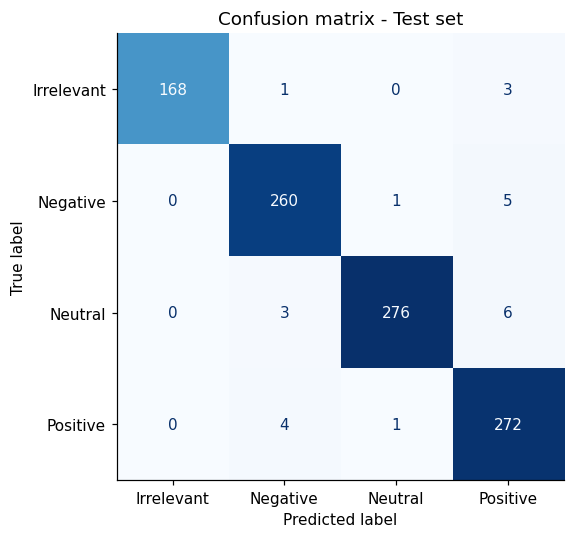

                 pred Irrelevant  pred Negative  pred Neutral  pred Positive
true Irrelevant              168              1             0              3
true Negative                  0            260             1              5
true Neutral                   0              3           276              6
true Positive                  0              4             1            272


In [20]:
# ============================================================================ #
#  חלק 5ד: מטריצת הבלבול                                                      #
# ============================================================================ #
labels = list(final_model.classes_)
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(5.6, 5.0))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, cmap="Blues",
                                                       colorbar=False, values_format="d")
ax.set_title("Confusion matrix - Test set")
ax.grid(False)
plt.tight_layout(); plt.show()

print(pd.DataFrame(cm,
                   index=[f"true {c}" for c in labels],
                   columns=[f"pred {c}" for c in labels]).to_string())

### למה הציון על ה-Test יצא גבוה מהערכת ה-Cross-Validation?

הציון על ה-Test יצא **גבוה** מהערכת ה-Cross-Validation, וזה מפתיע: בדרך כלל מצפים לכיוון ההפוך. במקום להניח הסבר, נבדוק אותו.

החשד נעוץ בדאטהסט עצמו: הוא בנוי כך שלכל ציוץ יש כמה ניסוחים חלופיים — הסתכלו שוב על חמש השורות הראשונות של ה-Train Set, כולן וריאציות של אותו משפט עם אותו `Tweet_ID` — וייתכן שחלק מהניסוחים האלה מופיעים גם בקובץ ה-Test. אם כך, המודל פשוט "זוכר" ציוצים שראה. התא הבא מפצל את ה-Test לשתי תת-קבוצות — ציוצים שמופיעים גם באימון וציוצים שלא — ומודד כל אחת בנפרד.

In [21]:
# ============================================================================ #
#  כמה מה-Test Set הוא בכלל ציוץ שהמודל כבר ראה באימון?                       #
# ============================================================================ #
def squash(s):
    """Identity key that ignores punctuation, spacing and case, so that two
    phrasings of the same tweet collapse onto the same string."""
    return re.sub(r"[^a-z0-9]", "", str(s).lower())


train_seen = {squash(t) for t in train_fit["Tweet_Text"]}
unseen = np.array([squash(t) not in train_seen for t in test_df["Tweet_Text"]])

print(f"{'subset':<46}{'n':>6}{'macro-F1':>11}")
print("-" * 63)
print(f"{'FULL test set (reported as the final metric)':<46}{len(y_test):>6}{macro_f1:>11.4f}")
print(f"{'  of which: also present in the training file':<46}{(~unseen).sum():>6}"
      f"{f1_score(y_test[~unseen], y_pred[~unseen], average='macro'):>11.4f}")
print(f"{'  of which: genuinely unseen tweets':<46}{unseen.sum():>6}"
      f"{f1_score(y_test[unseen], y_pred[unseen], average='macro'):>11.4f}")
print(f"\n  5-fold cross-validation estimate (Part 6a)  : {best['mean_macro_f1']:.4f}")

subset                                             n   macro-F1
---------------------------------------------------------------
FULL test set (reported as the final metric)    1000     0.9772
  of which: also present in the training file    716     0.9910
  of which: genuinely unseen tweets              284     0.9382

  5-fold cross-validation estimate (Part 6a)  : 0.9249


### מה הבדיקה מלמדת

החשד אושש. כ-72% מציוצי ה-Test (716 מתוך 1,000) מופיעים גם בקובץ ה-Training בניסוח כמעט זהה, והציון עליהם — 0.9910 — גבוה בבירור מהציון על הציוצים שהמודל לא ראה מעולם, 0.9382. זו תכונה של הדאטהסט עצמו כפי שפורסם ולא באג בפרוטוקול שלנו: ההנחיות אוסרות לחלק את הקבצים מחדש, ולכן אנחנו מדווחים את המדד הנדרש על כל ה-Test Set, ולצידו את הפילוח הכן.

**והנקודה החזקה באמת:** הציון על הציוצים החדשים לגמרי (0.9382) קרוב מאוד להערכת ה-Cross-Validation (0.9249). שני אומדנים שחושבו בשתי דרכים שונות לחלוטין — אחד על ה-Train בחלוקה ל-Folds, השני על תת-קבוצה של ה-Test — נחתו כמעט על אותו מספר. זו העדות החזקה ביותר שיש לנו לכך שהפרוטוקול תקין ושאין דליפת מידע מהצד שלנו. הציון הרשמי של העבודה הוא זה שעל כל ה-Test Set, והמספר שמשקף את יכולת ההכללה האמיתית של המודל על ציוץ חדש הוא 0.9382.

## סיכום

| חלק | מה עשינו | התוצאה |
|---|---|---|
| 1 | טענו את שני הקבצים כפי שהם, בלי חלוקה מחדש; הצגנו את 5 השורות הראשונות של כל אחד | 74,682 שורות Train, 1,000 שורות Test |
| 2 | ניקוי סטייטלס (אותיות קטנות, הסרת קישורים, תיוגים ותווים לא-אלפביתיים) ואחריו ייצוג מספרי שמאומן על ה-Train בלבד | הוצג לפני/אחרי על 3 דוגמאות מכל סט |
| 3 | מימשנו Multinomial Naive Bayes מאפס במרחב לוגריתמי עם החלקת לפלס, ואימתנו מול `sklearn` | הפרש בסדר גודל של שגיאת עיגול ($10^{-15}$) |
| 6א | מכפלה קרטזית של 64 תצורות, כל אחת ב-5-Fold Cross Validation, על ה-Train בלבד | 320 אימונים; המנצחת: `tfidf`, `(1,2)`, אוצר מילים מלא, $\alpha=0.1$ — ציון 0.9249 |
| 4 | אימון מחדש של התצורה המנצחת על כל ה-Train, והצגת המסלול של 3 דוגמאות | 73,624 שורות, 271,616 מאפיינים |
| 5 | אותו preprocessing על ה-Test, 5 חיזויים ראשונים, Macro-F1, דוח סיווג ומטריצת בלבול | **Macro-F1 = 0.9772** |

---

### נקודות מפתח

1. **הזרימה במלואה:** טעינה ← ניקוי טקסט ← ייצוג מספרי ← Naive Bayes עם החלקת לפלס ← בחירת התצורה ב-Grid Search עם 5-Fold Cross Validation ← אימון סופי על כל ה-Train ← מבחן יחיד על ה-Test.

2. **ההבחנה המרכזית בכל העבודה** היא מה מאומן על ה-Train בלבד ומה לא. זו הסיבה שה-Vectorizer מאומן מחדש בתוך כל Fold, וזו הסיבה שה-Test Set לא השתתף בשום שלב בבחירת התצורה.

3. **למה Macro-F1 ולא Accuracy:** ארבע מחלקות ואין ביניהן מחלקה מרכזית אחת, ולכן המחלקה הקטנה ביותר צריכה לקבל משקל זהה לגדולה.

4. **החלקת לפלס:** בלעדיה, מילה אחת שלא נראתה באימון מאפסת את כל המכפלה ומוציאה מחלקה שלמה מהמשחק.

5. **מרחב הלוג:** מכפלה של אלפי הסתברויות קטנות נעלמת לאפס בייצוג המספרי של המחשב; המעבר ללוג הופך אותה לסכום, וגם מאפשר לחשב את כל החיזויים בכפל מטריצות אחד.

6. **הציר שהכי השפיע הוא `max_features`** (0.8005 מול 0.6133). ההגבלה ל-5,000 מילים נראית תמימה, ובפועל היא זורקת בדיוק את המילים הנדירות שהן האות החזק ביותר לסנטימנט. זו הדגמה לכך שאסור לקבע היפר-פרמטרים "לפי תחושה" במקום לבדוק אותם.
